# Training with Deistler Summary Statistics Loss

Uses the Deistler et al. (2025) loss function: MAE over 4 standardized summary statistics
(mean and std in pre-stimulus and stimulus windows, normalized by /8.0 and /4.0).

This loss is fully differentiable without surrogate gradient tricks in the loss itself —
it only depends on voltage trace statistics, not discrete spike events.

Two-stage approach:
1. **Stage 1**: Train membrane parameters (g_L, E_L, v_T, v_reset, C_m)
2. **Stage 2**: Train adaptation parameters (a, b, tau_w)

In [1]:
import logging

import jax
import jax.numpy as jnp
import numpy as np
from jax import config

from ADoptEX.core.data import crop_to_stim_window, load_trace
from ADoptEX.core.parameters import DEFAULT_PARAMS, PARAM_BOUNDS, NAUD_PARAMETERS
from ADoptEX.core.simulation import simulate_jaxley
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    make_deistler_loss_fn,
    DeistlerLossConfig,
)
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_stim_window_plot,
    training_comparison_plot,
    training_history_plot,
)
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

## 1. Load Data

In [2]:
DATA_DIR = "/Users/paulmayer/Projects/university/40_thesis/4_data/models/optimisations/mCP-dspn-e150917_c6_D1-manimal_1_n24_04102017_cel1/expdata/"

trace = load_trace(
    voltage_path=DATA_DIR + "ECBL_IDthresh_ch5_553.dat",
    current_path=DATA_DIR + "ECBL_IDthresh_ch4_553.dat",
)

print(
    f"Loaded trace: {trace.n_samples} samples, dt={trace.dt_ms:.3f} ms, duration={trace.duration_ms:.1f} ms"
)
print(
    f"Stim window: {trace.stim_start_idx} - {trace.stim_end_idx} ({trace.stim_duration_ms:.1f} ms)"
)
print(f"Stim current: {trace.stim_current_pA:.1f} pA")
print(f"Detected spikes: {trace.n_spikes}")

Loaded trace: 30000 samples, dt=0.100 ms, duration=2999.9 ms
Stim window: 7001 - 27001 (2000.0 ms)
Stim current: 421.3 pA
Detected spikes: 46


Cropped trace: 5000 samples, 500.0 ms
Spikes in window: 13 at [ 35.   72.  109.3 147.6 181.6 218.1 253.3 292.8 330.2 366.2 399.5 437.2
 475.1] ms
Stim indices: start=0, end=5000


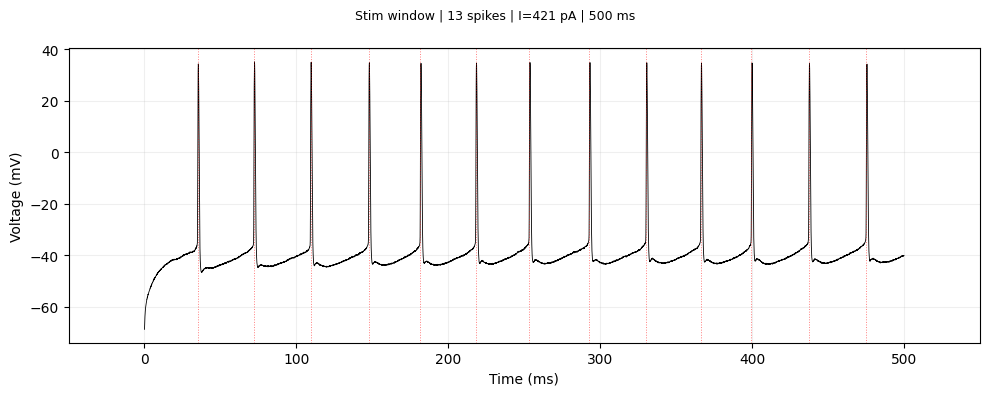

In [3]:
# Crop to stimulation window (500 ms max)
data = crop_to_stim_window(trace, max_duration_ms=500.0)

print(f"Cropped trace: {data.n_samples} samples, {data.stim_duration_ms:.1f} ms")
print(f"Spikes in window: {data.n_spikes} at {data.spike_times.round(1)} ms")
print(f"Stim indices: start={data.stim_start_idx}, end={data.stim_end_idx}")

trace_stim_window_plot(data);

## 2. Initial Simulation

INFO:2026-02-23 16:54:48,258:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Initial simulation: 43 spikes, firing rate 71.7 Hz
Experimental:       13 spikes
{'C_m': 200.0, 'g_L': 10.0, 'E_L': -70.0, 'v_T': -50.0, 'delta_T': 2.0, 'v_reset': -58.0, 'v_threshold': 0.0, 'tau_w': 30.0, 'a': -0.5, 'b': 10.0, 'I': 500.0}


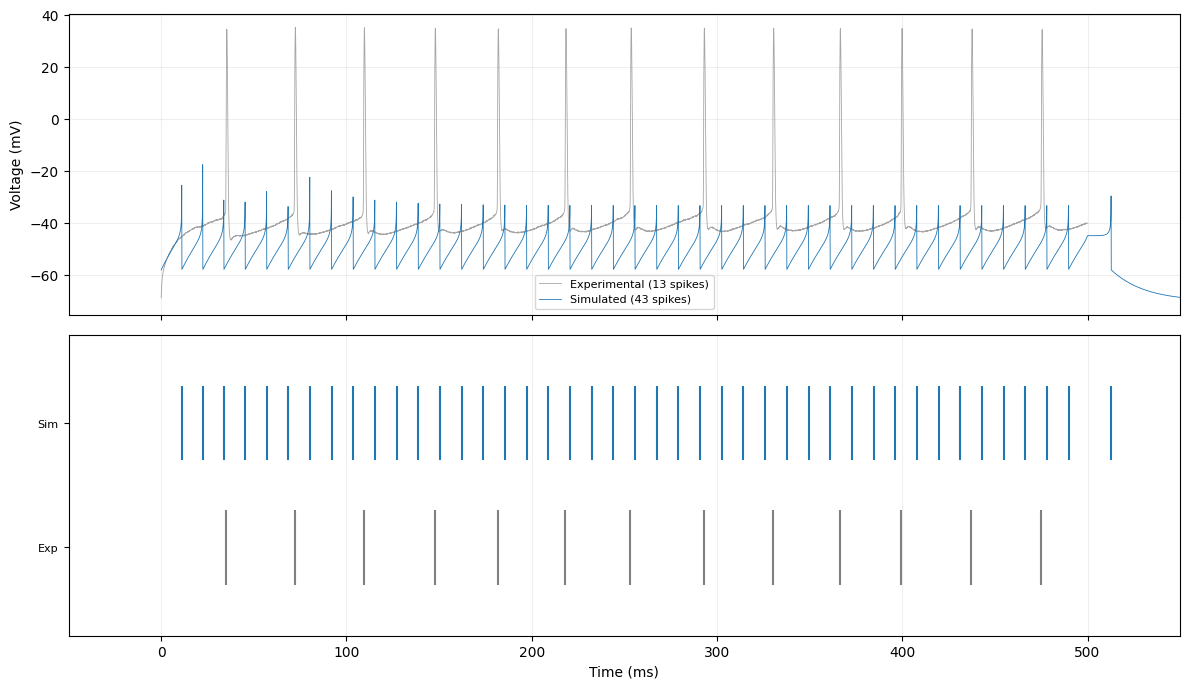

In [4]:
initial_params = dict(NAUD_PARAMETERS["tonic"])
initial_params["v_threshold"] = 0.0
initial_params["a"] = -0.5
initial_params["b"] = 10.0

sim_init = simulate_jaxley(
    params=initial_params,
    stim_current_pA=data.stim_current_pA,
    stim_duration_ms=data.stim_duration_ms,
    dt_ms=data.dt_ms,
    use_surrogate=True,
)

print(
    f"Initial simulation: {sim_init.n_spikes} spikes, firing rate {sim_init.firing_rate_hz:.1f} Hz"
)
print(f"Experimental:       {data.n_spikes} spikes")

fit_comparison_plot(data, sim_init)
print(initial_params)

## 3. Stage 1 — Deistler Loss (Membrane Parameters)

In [5]:
# Convert current trace to nA (Jaxley units, scaled by C_m)
current_nA = jnp.array(data.current * initial_params["C_m"] / 1000.0)
target_voltage = jnp.array(data.voltage)

# --- Stage 1 config: Polyak optimizer, sigmoid reparameterization ---
config_stage1 = TrainingConfig(
    optimizer="polyak",
    learning_rate=0.005,
    n_epochs=50,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
    print_every=10,
    polyak_alpha=1.0,
    polyak_beta=0.85,
    clip_to_bounds=False,
    use_param_transform=True,
    verbose=True,
    return_best=True,
)

# Create trainable cell
cell1, data_stimuli1, t_max1, trainable_params1 = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_nA=current_nA,
    dt_ms=data.dt_ms,
    config=config_stage1,
    trainable_params=["g_L", "E_L", "v_T", "v_reset", "C_m"],
)

# Deistler loss with spike peak injection
loss_fn_stage1 = make_deistler_loss_fn(
    cell=cell1,
    data_stimuli=data_stimuli1,
    t_max=t_max1,
    dt_ms=data.dt_ms,
    exp_voltage=target_voltage,
    stim_start_index=data.stim_start_idx,
    stim_end_index=data.stim_end_idx,
    loss_config=DeistlerLossConfig(spike_peak_mv=35.0),
)

print(f"Initial Deistler loss: {float(loss_fn_stage1(trainable_params1)):.4f}")
print(trainable_params1)

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Initial Deistler loss: 0.8551
[{'AdEx_g_L': Array([10.], dtype=float32)}, {'AdEx_E_L': Array([-70.], dtype=float32)}, {'AdEx_v_T': Array([-50.], dtype=float32)}, {'AdEx_v_reset': Array([-58.], dtype=float32)}, {'capacitance': Array([200.], dtype=float32)}]


In [6]:
result_stage1 = train(
    loss_fn=loss_fn_stage1,
    trainable_params=trainable_params1,
    config=config_stage1,
    initial_params=initial_params,
)

print(f"\nStage 1 complete.")
print(f"  Best loss:   {result_stage1.best_loss:.4f}")
print(f"  Total time:  {result_stage1.total_time:.1f} s")

Training: optimizer=polyak lr=0.005 epochs=50 surrogate=sigmoid slope=5.0 alpha=1.0 beta=0.85 sigmoid_transform
Epoch    0 | loss=0.855137 | grad_norm=9.30e+00 | lr=4.28e-03 | g_L=9.9848, E_L=-69.9790, v_T=-50.0218, v_reset=-57.9745, C_m=199.6897
Epoch   10 | loss=0.776009 | grad_norm=7.15e+02 | lr=3.88e-03 | g_L=9.9191, E_L=-69.8987, v_T=-50.0937, v_reset=-57.8391, C_m=198.5748
Epoch   20 | loss=0.575045 | grad_norm=4.00e+00 | lr=2.88e-03 | g_L=8.8814, E_L=-68.4313, v_T=-51.8396, v_reset=-55.2283, C_m=177.6331
NaN gradients at epoch 21 — stopping early
Training complete: final_loss=0.575045 best_loss=0.572739 (epoch 15) total_time=9.6s mean_epoch=458.8ms lr=4.28e-03->2.88e-03 [returning best]



Stage 1 complete.
  Best loss:   0.5727
  Total time:  9.6 s


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.


/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:86: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


Added 1 external_states. See `.externals` for details.
Stage 1: 75 spikes (target: 13)
Gamma = -0.045


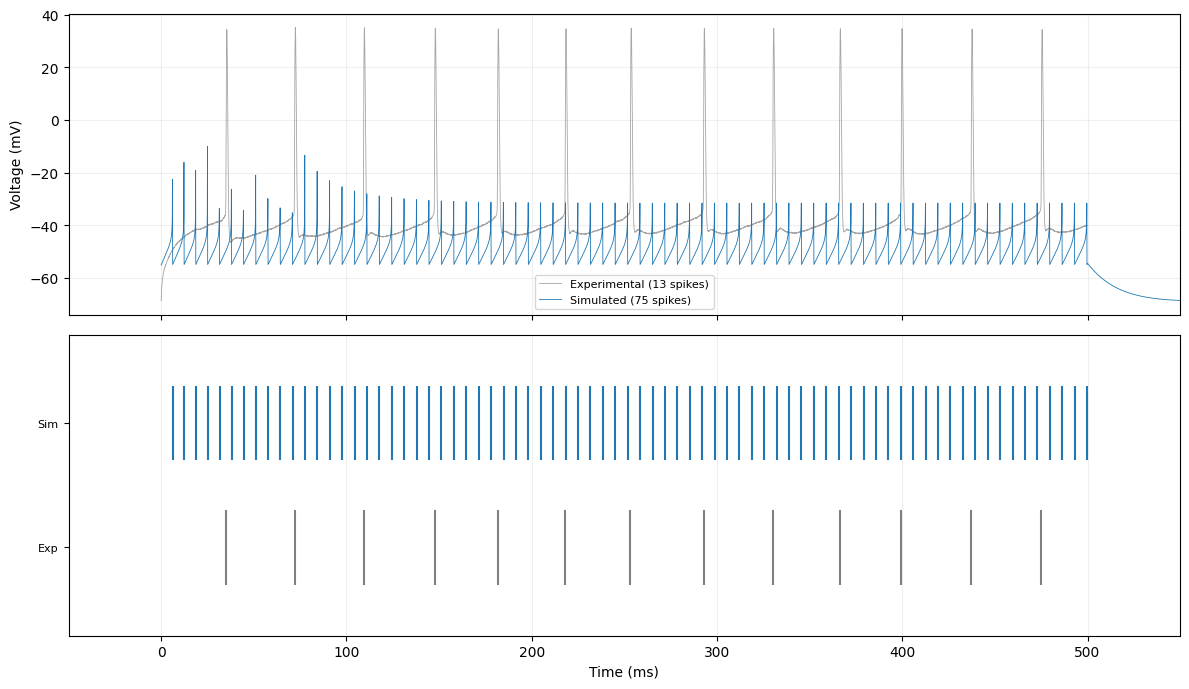

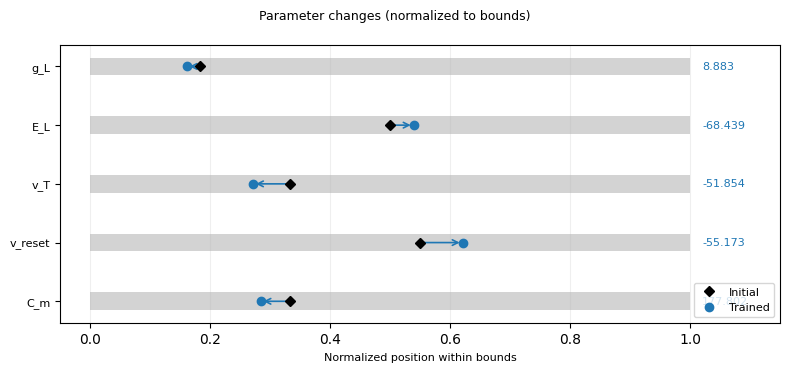

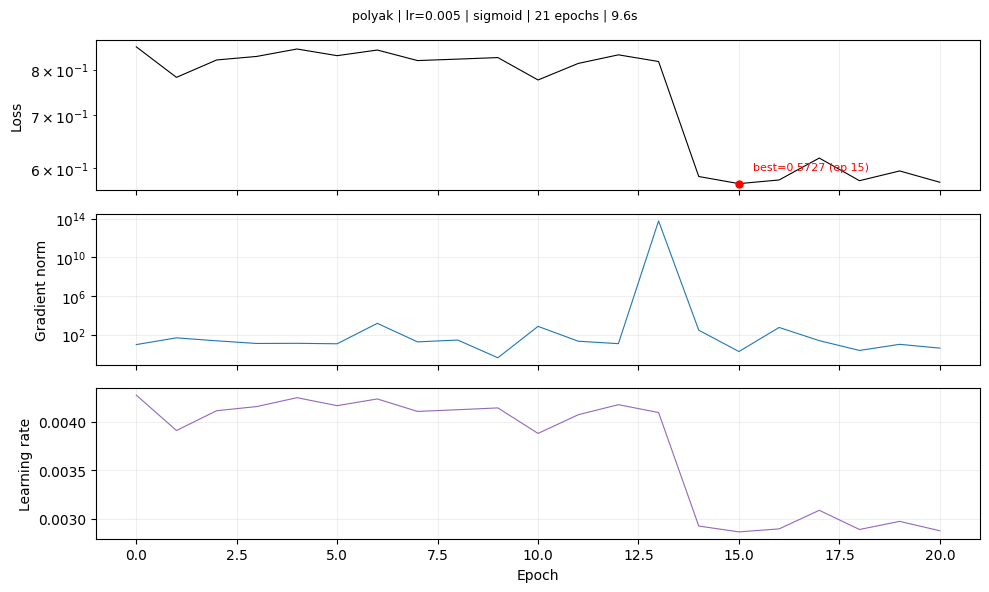

In [7]:
# Evaluate stage 1: simulate and check spike count + Gamma
trained_s1 = result_stage1.get_params_dict()
params_after_s1 = dict(initial_params)
params_after_s1.update(trained_s1)

sim_stage1 = simulate_jaxley(
    params=params_after_s1,
    stim_current_pA=data.stim_current_pA,
    stim_duration_ms=data.stim_duration_ms,
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Stage 1: {sim_stage1.n_spikes} spikes (target: {data.n_spikes})")

if sim_stage1.n_spikes > 0 and data.n_spikes > 0:
    cf_s1 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_stage1.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=2,
    )
    print(f"Gamma = {cf_s1.gamma:.3f}")
else:
    cf_s1 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_stage1)
parameter_comparison_plot(result_stage1)
training_history_plot(result_stage1);

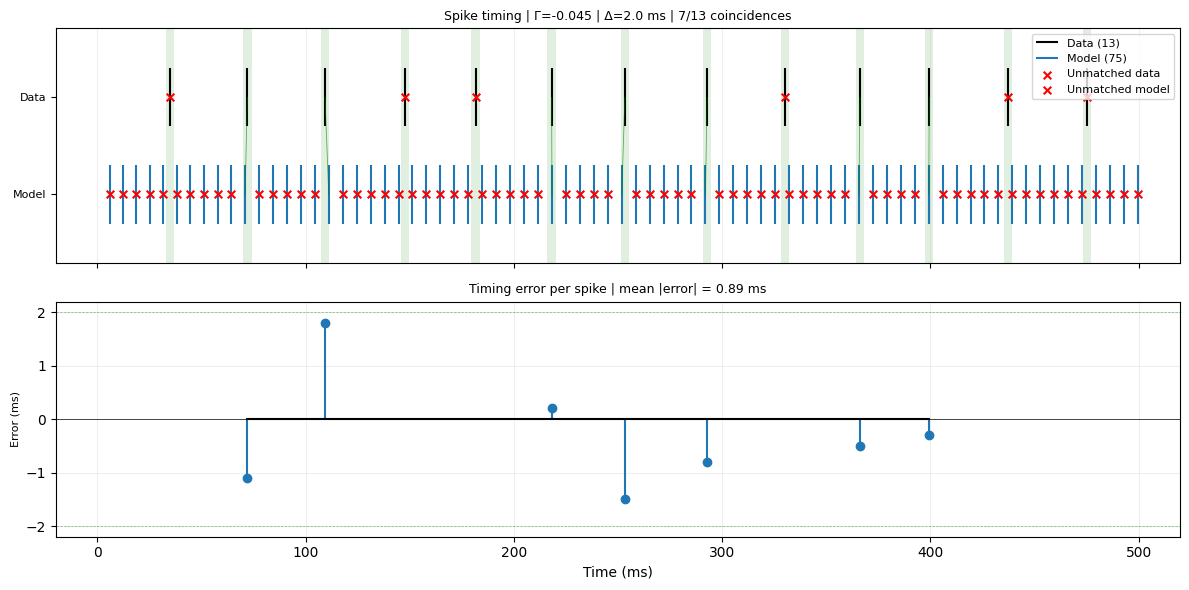

In [8]:
if cf_s1 is not None:
    spike_timing_plot(data, sim_stage1, cf_s1);

## 4. Stage 2 — Deistler Loss (Adaptation Parameters)

In [9]:
# Stage 2 starts from stage 1's trained parameters
stage2_params = dict(initial_params)
stage2_params.update(result_stage1.get_params_dict())

print("Stage 2 initial parameters (from stage 1):")
for k, v in result_stage1.get_params_dict().items():
    init_v = initial_params.get(k, float("nan"))
    print(f"  {k:<12} {init_v:>10.3f} -> {v:>10.3f}")

# --- Stage 2 config: Polyak optimizer, sigmoid reparameterization ---
config_stage2 = TrainingConfig(
    optimizer="polyak",
    learning_rate=0.005,
    n_epochs=50,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
    print_every=10,
    polyak_alpha=1.0,
    polyak_beta=0.85,
    clip_to_bounds=False,
    use_param_transform=True,
    verbose=True,
    return_best=True,
)

# Re-create cell for stage 2
cell2, data_stimuli2, t_max2, trainable_params2 = setup_trainable_cell(
    initial_params=stage2_params,
    current_trace_nA=current_nA,
    dt_ms=data.dt_ms,
    config=config_stage2,
    trainable_params=["a", "b", "tau_w"],
)

# Deistler loss with spike peak injection
loss_fn_stage2 = make_deistler_loss_fn(
    cell=cell2,
    data_stimuli=data_stimuli2,
    t_max=t_max2,
    dt_ms=data.dt_ms,
    exp_voltage=target_voltage,
    stim_start_index=data.stim_start_idx,
    stim_end_index=data.stim_end_idx,
    loss_config=DeistlerLossConfig(spike_peak_mv=35.0),
)

print(f"\nInitial Stage 2 loss: {float(loss_fn_stage2(trainable_params2)):.4f}")

Stage 2 initial parameters (from stage 1):
  g_L              10.000 ->      8.883
  E_L             -70.000 ->    -68.439
  v_T             -50.000 ->    -51.854
  v_reset         -58.000 ->    -55.173
  C_m             200.000 ->    177.802
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3

Initial Stage 2 loss: 0.6680


In [10]:
result_stage2 = train(
    loss_fn=loss_fn_stage2,
    trainable_params=trainable_params2,
    config=config_stage2,
    initial_params=stage2_params,
)

print(f"\nStage 2 complete.")
print(f"  Best loss:   {result_stage2.best_loss:.4f}")
print(f"  Total time:  {result_stage2.total_time:.1f} s")

Training: optimizer=polyak lr=0.005 epochs=50 surrogate=sigmoid slope=5.0 alpha=1.0 beta=0.85 sigmoid_transform
Epoch    0 | loss=0.668018 | grad_norm=4.82e+00 | lr=3.34e-03 | a=-0.4819, b=10.0174, tau_w=30.0225
Epoch   10 | loss=0.626539 | grad_norm=3.60e-01 | lr=3.13e-03 | a=-0.3210, b=10.1724, tau_w=30.1749
Epoch   20 | loss=0.627534 | grad_norm=2.72e+01 | lr=3.14e-03 | a=-0.3417, b=10.1494, tau_w=30.1601
Epoch   30 | loss=0.634585 | grad_norm=inf | lr=3.17e-03 | a=-0.3029, b=10.1870, tau_w=30.2009
Epoch   40 | loss=0.634585 | grad_norm=inf | lr=3.17e-03 | a=-0.3029, b=10.1870, tau_w=30.2009
Training complete: final_loss=0.634585 best_loss=0.625675 (epoch 11) total_time=18.1s mean_epoch=361.3ms lr=3.34e-03->3.17e-03 [returning best]



Stage 2 complete.
  Best loss:   0.6257
  Total time:  18.1 s


## 5. Results

In [11]:
# Final simulation with stage 2 parameters
trained_s1 = result_stage1.get_params_dict()
trained_s2 = result_stage2.get_params_dict()
params_final = dict(initial_params)
params_final.update(trained_s1)
params_final.update(trained_s2)

sim_final = simulate_jaxley(
    params=params_final,
    stim_current_pA=data.stim_current_pA,
    stim_duration_ms=data.stim_duration_ms,
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Final simulation: {sim_final.n_spikes} spikes (target: {data.n_spikes})")

if sim_final.n_spikes > 0 and data.n_spikes > 0:
    cf_final = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_final.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=2,
    )
    print(f"Coincidence factor Gamma = {cf_final.gamma:.3f} (target > 0.5)")
else:
    cf_final = None
    print("Coincidence factor: N/A (no spikes)")

# Compare with stage 1
if cf_s1 is not None:
    gamma_s2 = f"{cf_final.gamma:.3f}" if cf_final else "N/A"
    print(f"\nStage 1 Gamma: {cf_s1.gamma:.3f} -> Stage 2 Gamma: {gamma_s2}")

print(f"\nFinal parameters: {result_stage2.get_params_dict()}")

/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:86: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Final simulation: 74 spikes (target: 13)
Coincidence factor Gamma = -0.096 (target > 0.5)

Stage 1 Gamma: -0.045 -> Stage 2 Gamma: -0.096

Final parameters: {'a': -0.3541431427001953, 'b': 10.138773918151855, 'tau_w': 30.14356803894043}


In [12]:
# Show trained parameter values
print("Parameter progression: initial -> stage 1 -> stage 2")
print(
    f"{'Parameter':<12} {'Initial':>10} {'Stage 1':>10} {'Stage 2':>10} {'Bounds':>20}"
)
print("-" * 65)
for k in list(trained_s1.keys()) + list(trained_s2.keys()):
    init_v = initial_params.get(k, float("nan"))
    s1_v = trained_s1.get(k, init_v)
    s2_v = trained_s2.get(k, s1_v)
    bounds = PARAM_BOUNDS.get(k)
    bounds_str = f"[{bounds.min}, {bounds.max}]" if bounds else ""
    print(f"{k:<12} {init_v:>10.3f} {s1_v:>10.3f} {s2_v:>10.3f} {bounds_str:>20}")

Parameter progression: initial -> stage 1 -> stage 2
Parameter       Initial    Stage 1    Stage 2               Bounds
-----------------------------------------------------------------
g_L              10.000      8.883      8.883          [1.0, 50.0]
E_L             -70.000    -68.439    -68.439       [-90.0, -50.0]
v_T             -50.000    -51.854    -51.854       [-60.0, -30.0]
v_reset         -58.000    -55.173    -55.173       [-80.0, -40.0]
C_m             200.000    177.802    177.802        [50.0, 500.0]
a                -0.500     -0.500     -0.354        [-10.0, 10.0]
b                10.000     10.000     10.139         [0.0, 200.0]
tau_w            30.000     30.000     30.144        [10.0, 500.0]


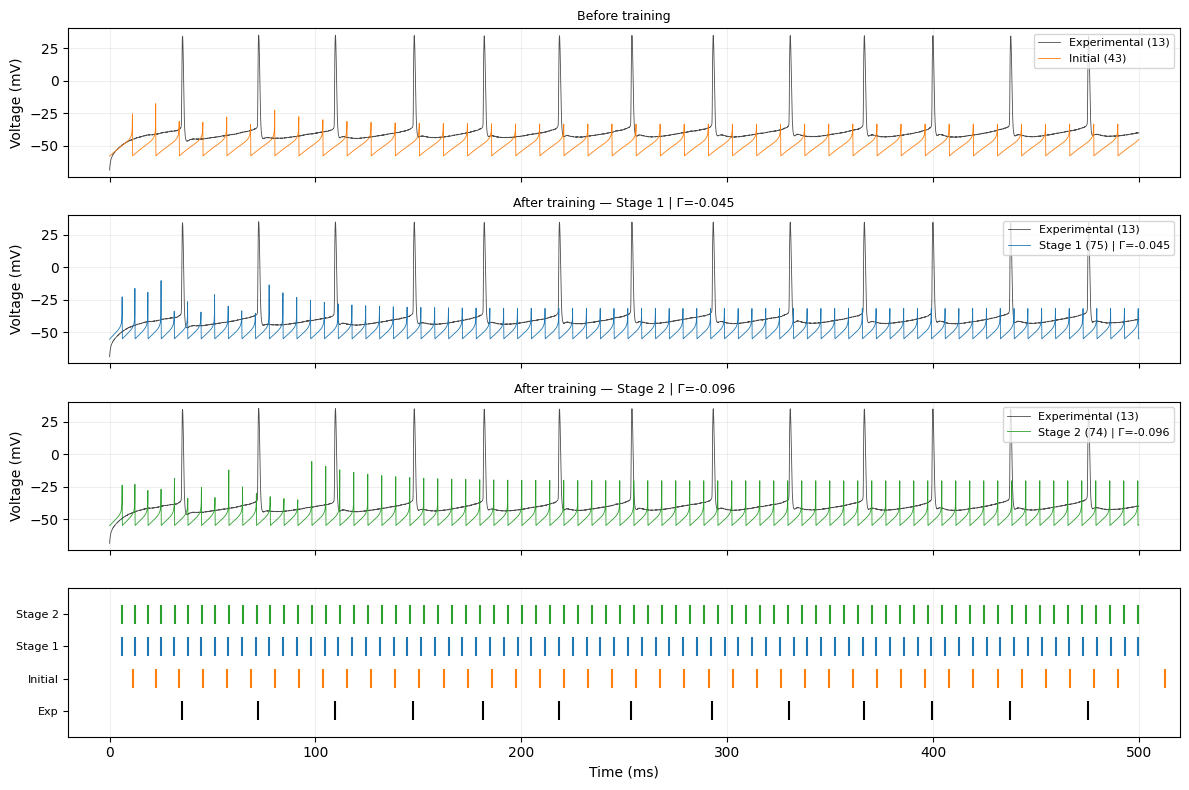

In [13]:
fit_before_after_plot(
    data,
    sim_init,
    [sim_stage1, sim_final],
    coincidence=[cf_s1, cf_final],
    labels=["Stage 1", "Stage 2"],
);

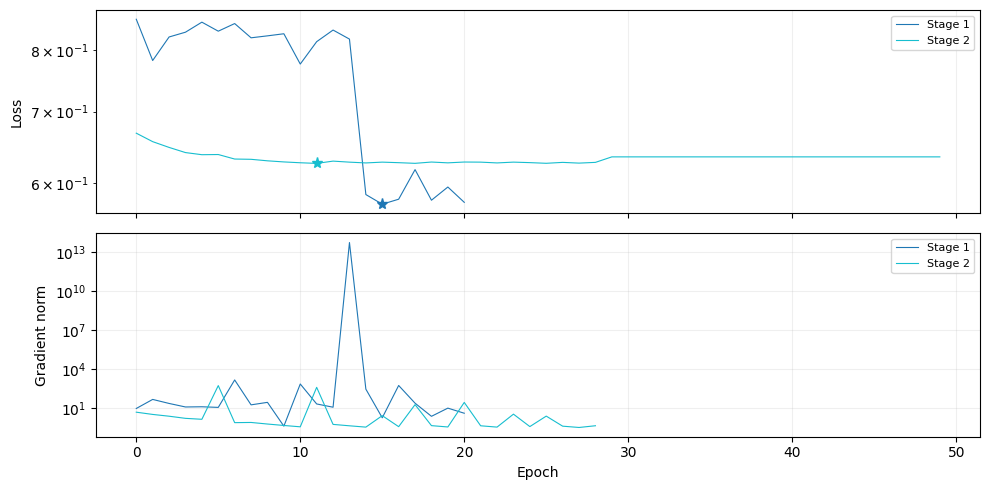

In [14]:
training_comparison_plot(
    [result_stage1, result_stage2],
    labels=["Stage 1", "Stage 2"],
    show_grad_norms=True,
);

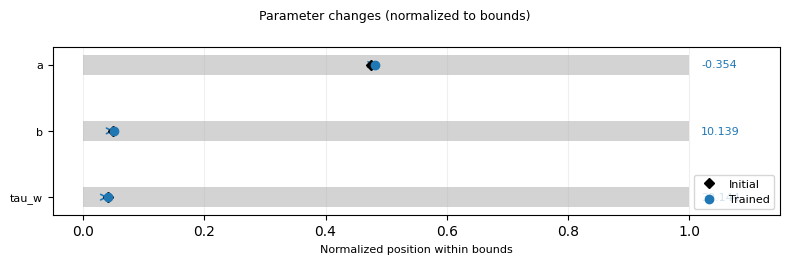

In [15]:
parameter_comparison_plot(result_stage2);

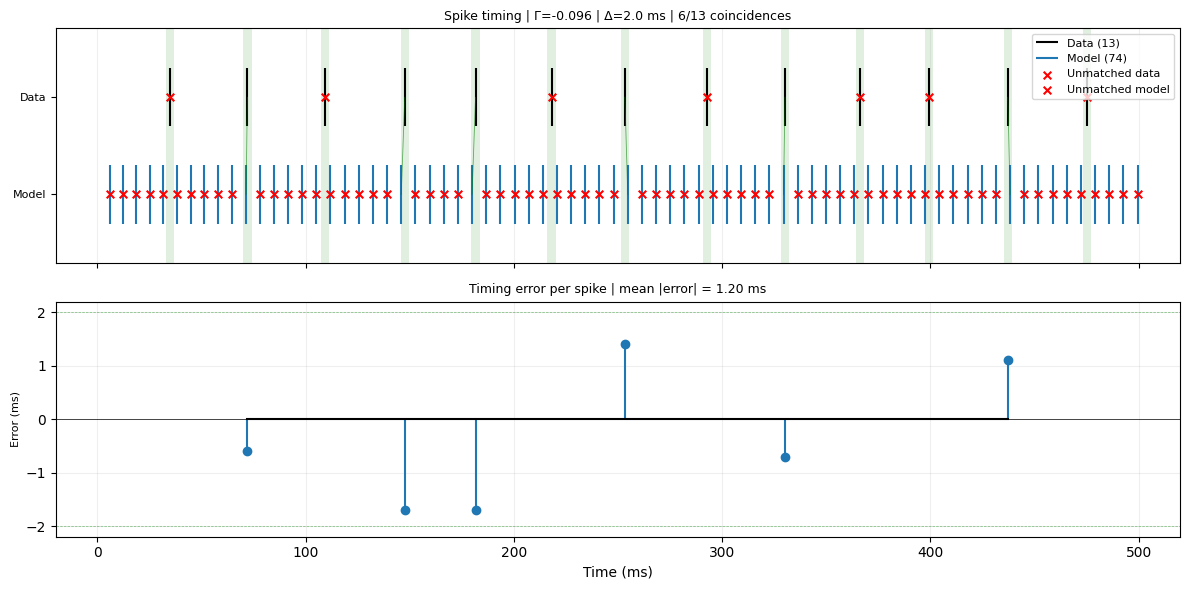

In [16]:
if cf_final is not None:
    spike_timing_plot(data, sim_final, cf_final)
else:
    print("Spike timing plot skipped (no spikes)")